# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [1]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

Note: you may need to restart the kernel to use updated packages.


In [2]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [3]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [8]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""
    # TODO: tokenize the text (hint: nltk.word_tokenize)
    tokens = nltk.word_tokenize(text.lower())
    # TODO: remove punctuation tokens
    # TODO: filter out stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    # TODO: lemmatize remaining tokens
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]
    # TODO: join back into a single cleaned string
    cleaned_string = " ".join(lemmatized_tokens)
    return cleaned_string

for review in raw_reviews:
    print(preprocess_text(review))

mcdonald food ok service bad
would recommend japanese restaurant anyone
loved restaurant traveled thailand last summer
menu loving wide variety option
staff friendly helpful google employee restaurant
ambiance bella italia amazing pasta dish delicious
terrible experience pizza hut pizza burnt service slow
sushi sushi express always fresh flavorful
steakhouse main street cozy atmosphere excellent steak
dessert selection sweet treat die


### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [10]:
# TODO: apply preprocess_text to every review and keep both raw and cleaned versions
cleaned_reviews = None
for review in raw_reviews:
    if cleaned_reviews is None:
        cleaned_reviews = []
    cleaned_reviews.append(preprocess_text(review))
if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")


RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW: The 

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [12]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    # TODO: run the spaCy pipeline on the text
    doc_spacy = nlp(text)
    # TODO: collect each entity text and its label_
    entities = [(ent.text, ent.label_) for ent in doc_spacy.ents]
    return entities

for cleaned_review in cleaned_reviews:
    print(perform_ner(cleaned_review))


[('mcdonald food ok service', 'ORG')]
[('japanese', 'NORP')]
[('thailand', 'GPE'), ('last summer', 'DATE')]
[]
[('google', 'ORG')]
[('ambiance bella italia', 'PERSON')]
[]
[]
[]
[]


### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [13]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    # TODO: tokenize the text
    tokens = nltk.word_tokenize(text)
    # TODO: call nltk.pos_tag on the tokens
    pos_tags = nltk.pos_tag(tokens)
    return pos_tags

for review in raw_reviews:
    print(perform_pos_tagging(review))

for review in cleaned_reviews:
    print(perform_pos_tagging(review))

[('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]
[('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]
[('I', 'PRP'), ('loved', 'VBD'), ('this', 'DT'), ('restaurant', 'NN'), ('when', 'WRB'), ('I', 'PRP'), ('traveled', 'VBD'), ('to', 'TO'), ('Thailand', 'NNP'), ('last', 'JJ'), ('summer', 'NN'), ('.', '.')]
[('The', 'DT'), ('menu', 'NN'), ('of', 'IN'), ('Loving', 'NNP'), ('has', 'VBZ'), ('a', 'DT'), ('wide', 'JJ'), ('variety', 'NN'), ('of', 'IN'), ('options', 'NNS'), ('.', '.')]
[('The', 'DT'), ('staff', 'NN'), ('was', 'VBD'), ('friendly', 'JJ'), ('and', 'CC'), ('helpful', 'JJ'), ('at', 'IN'), ('Google', 'NNP'), ("'s", 'POS'), ('employees', 'NNS'), ('restaurant', 'VBP'), ('.', '.')]
[('The', 'DT'), ('ambiance', 'NN'), ('a

### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [14]:
sample_texts = raw_reviews[:2]

print("NER on raw text")
# TODO: loop through sample_texts and print perform_ner results
for text in sample_texts:
    print(perform_ner(text))

print("\nNER on cleaned text")
# TODO: repeat using cleaned_reviews
for text in cleaned_reviews:
    print(perform_ner(text))
print("\nPOS tags on raw text")
# TODO
for text in sample_texts:
    print(perform_pos_tagging(text))
print("\nPOS tags on cleaned text")
# TODO
for text in cleaned_reviews:
    print(perform_pos_tagging(text))

NER on raw text
[('McDonald', 'ORG')]
[('Japanese', 'NORP')]

NER on cleaned text
[('mcdonald food ok service', 'ORG')]
[('japanese', 'NORP')]
[('thailand', 'GPE'), ('last summer', 'DATE')]
[]
[('google', 'ORG')]
[('ambiance bella italia', 'PERSON')]
[]
[]
[]
[]

POS tags on raw text
[('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]
[('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]

POS tags on cleaned text
[('mcdonald', 'NNS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]
[('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]
[('loved', 'VBN'), ('restaurant', 'NN'), ('traveled', 'VBN'), ('thailand', 'NN'), ('last', 'JJ'), ('summer', 'NN')]
[('menu', 'NN'

## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [17]:
from gensim.models import Word2Vec

# TODO: ensure cleaned_reviews is defined from Exercise 1
# Tokenize on whitespace after preprocessing
tokenized_reviews = [review.split() for review in cleaned_reviews]
# TODO: train the Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_reviews, 
    vector_size=100,    # Dimensionality of the word vectors
    window=5,           # Maximum distance between current and predicted word
    min_count=2,        # Ignores words with total frequency lower than this
    workers=4           # Number of CPU cores to use for training
)
w2v_model


### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [18]:
# TODO: print the vector size and vocabulary size of your model
# 1. Print the vector size (number of dimensions per word)
print(f"Vector Size: {w2v_model.wv.vector_size}")

# 2. Print the vocabulary size (number of unique words the model learned)
print(f"Vocabulary Size: {len(w2v_model.wv)}")

Vector Size: 100
Vocabulary Size: 4


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

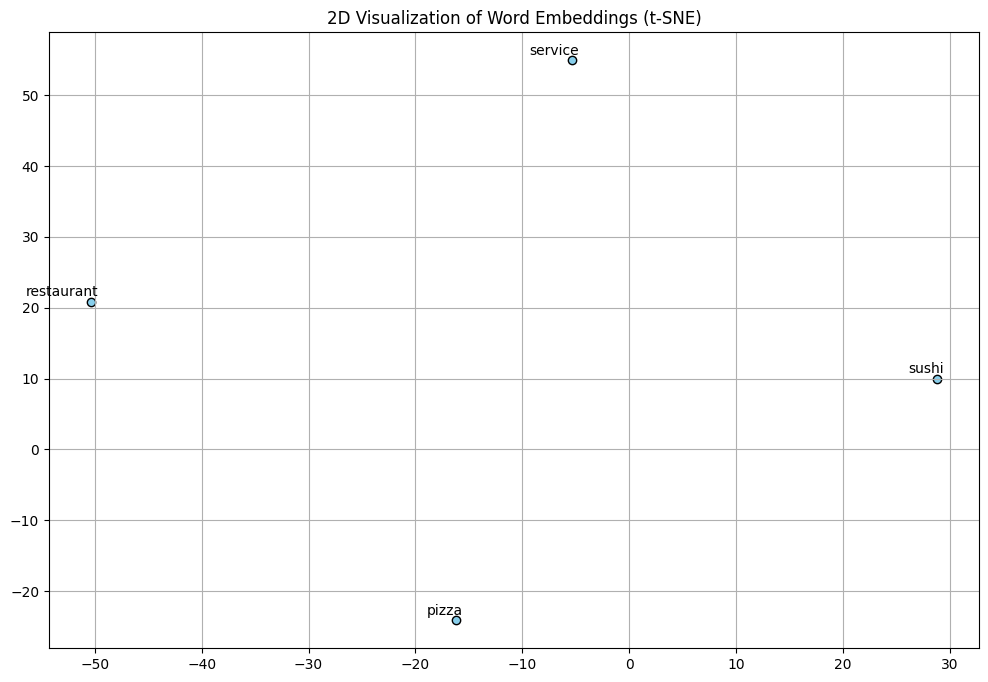

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


# TODO: complete the plot_word_embeddings function
def plot_word_embeddings(model, words=None):
    """Visualizes word embeddings in 2D space using t-SNE."""
    if words is None:
        # Fallback: just take the first 50 words in the vocabulary
        words = list(model.wv.index_to_key)[:50]
    
    # 1. Extract the vectors for the chosen words
    word_vectors = np.array([model.wv[word] for word in words])
    
    # 2. Reduce dimensions from (e.g.) 100 to 2
    tsne = TSNE(n_components=2, random_state=42, perplexity=len(words)-1)
    embeddings_2d = tsne.fit_transform(word_vectors)
    
    # 3. Create the plot
    plt.figure(figsize=(12, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], edgecolors='k', c='skyblue')
    
    # 4. Annotate the points with the words
    for i, word in enumerate(words):
        plt.annotate(word, xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]), xytext=(5, 2),
                     textcoords='offset points', ha='right', va='bottom')
    
    plt.title("2D Visualization of Word Embeddings (t-SNE)")
    plt.grid(True)
    plt.show()

# TODO: call the plotting function using your trained model
plot_word_embeddings(w2v_model)


### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

In [22]:
from gensim.models.phrases import Phrases, Phraser

# Train a bigram detector
phrases = Phrases(tokenized_reviews, min_count=5, threshold=10)
bigram_transformer = Phraser(phrases)

# Apply it to your data
tokenized_bigrams = [bigram_transformer[review] for review in tokenized_reviews]

# Now train Word2Vec on tokenized_bigrams instead


# Train Word2Vec on the bigram data
w2v_model_bigrams = Word2Vec(
    sentences=tokenized_bigrams, 
    vector_size=100, 
    window=5, 
    min_count=2, 
    workers=4
)

# Extract all learned tokens that are bigrams (contain an underscore)
learned_bigrams = [word for word in w2v_model_bigrams.wv.index_to_key if '_' in word]

print(f"Total Bigrams Found: {len(learned_bigrams)}")
print("Sample Bigrams:", learned_bigrams[:10])

# If 'data_analyst' was found, let's see what is similar to it
word_to_test = learned_bigrams[0] if learned_bigrams else "salary"

print(f"\nWords most similar to '{word_to_test}':")
if word_to_test not in w2v_model_bigrams.wv:
    if len(w2v_model_bigrams.wv.index_to_key) > 0:
        word_to_test = w2v_model_bigrams.wv.index_to_key[0]
        print(f"Falling back to vocabulary word '{word_to_test}'")
    else:
        print("Model vocabulary is empty; cannot compute similarities.")
        word_to_test = None

if word_to_test is not None:
    for word, score in w2v_model_bigrams.wv.most_similar(word_to_test, topn=5):
        print(f"{word}: {score:.4f}")

Total Bigrams Found: 0
Sample Bigrams: []

Words most similar to 'salary':
Falling back to vocabulary word 'restaurant'
sushi: -0.0108
pizza: -0.0523
service: -0.1117


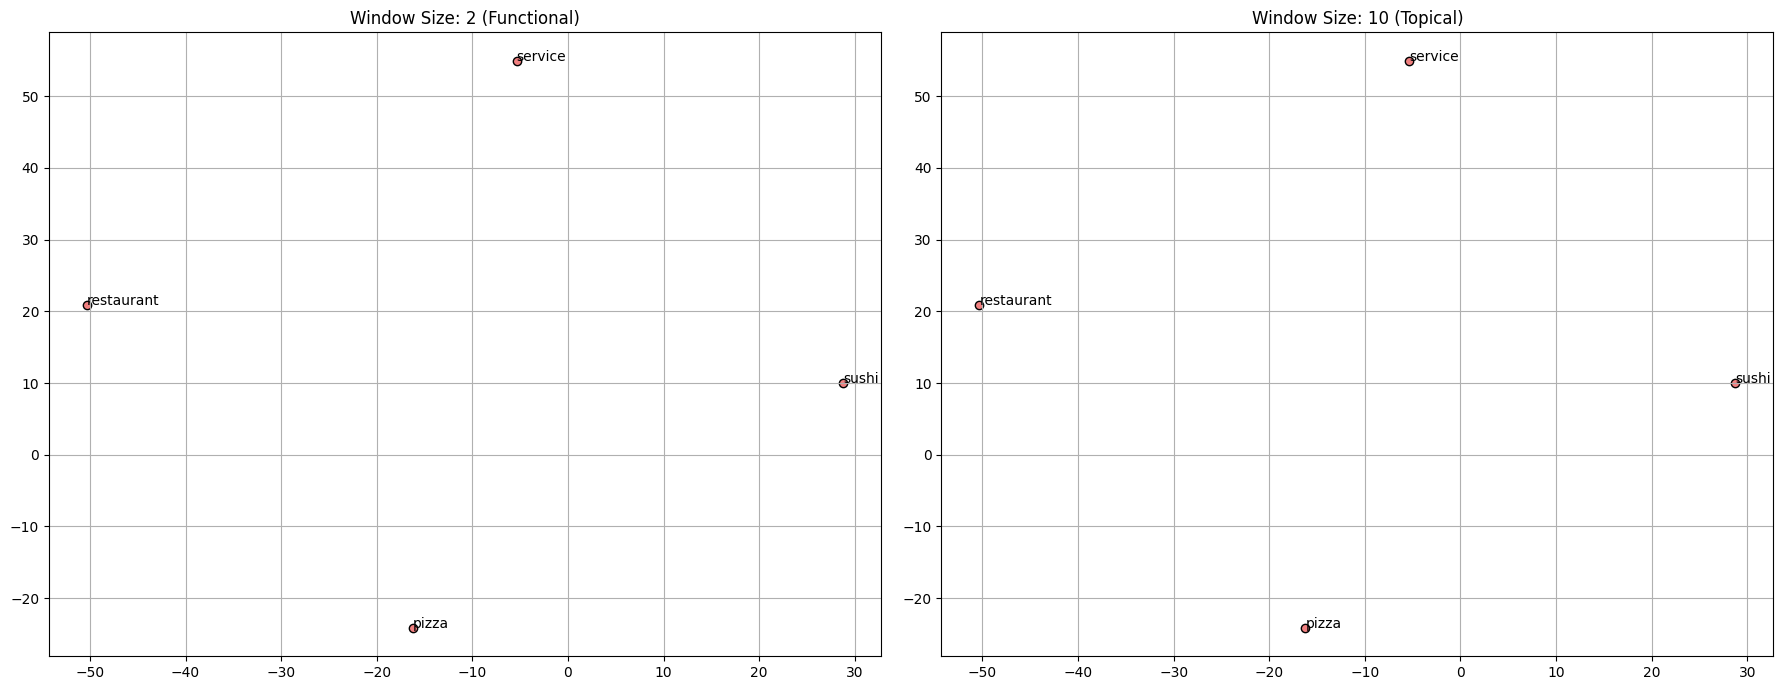

In [25]:

# Model A: Focus on local context (Synonyms)
model_small_window = Word2Vec(
    sentences=tokenized_bigrams, 
    vector_size=100, 
    window=2, 
    min_count=2
)

# Model B: Focus on global context (Topics)
model_large_window = Word2Vec(
    sentences=tokenized_bigrams, 
    vector_size=100, 
    window=10, 
    min_count=2
)


def compare_word_plots(models, titles, target_words):
    fig, axes = plt.subplots(1, len(models), figsize=(18, 7))
    
    for ax, model, title in zip(axes, models, titles):
        # Filter target words that exist in the model vocabulary
        valid_words = [w for w in target_words if w in model.wv]
        vectors = np.array([model.wv[w] for w in valid_words])
        
        # Dimensionality reduction
        # Ensure perplexity is valid: must be < n_samples and > 0
        perplexity = max(1, min(len(valid_words) - 1, 5.0))
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
        reduced = tsne.fit_transform(vectors)
        
        # Plotting
        ax.scatter(reduced[:, 0], reduced[:, 1], edgecolors='k', c='lightcoral')
        for i, word in enumerate(valid_words):
            ax.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=10)
        
        ax.set_title(title)
        ax.grid(True)

    plt.tight_layout()
    plt.show()

# Run the comparison
target_words = ['salary', 'bonus', 'pay', 'manager', 'lead', 'training', 'skills', 'remote']
target_words = [w for w in target_words if w in model_small_window.wv or w in model_large_window.wv]
if not target_words:
    target_words = model_small_window.wv.index_to_key[:8]
compare_word_plots(
    [model_small_window, model_large_window], 
    ["Window Size: 2 (Functional)", "Window Size: 10 (Topical)"],
    target_words
)

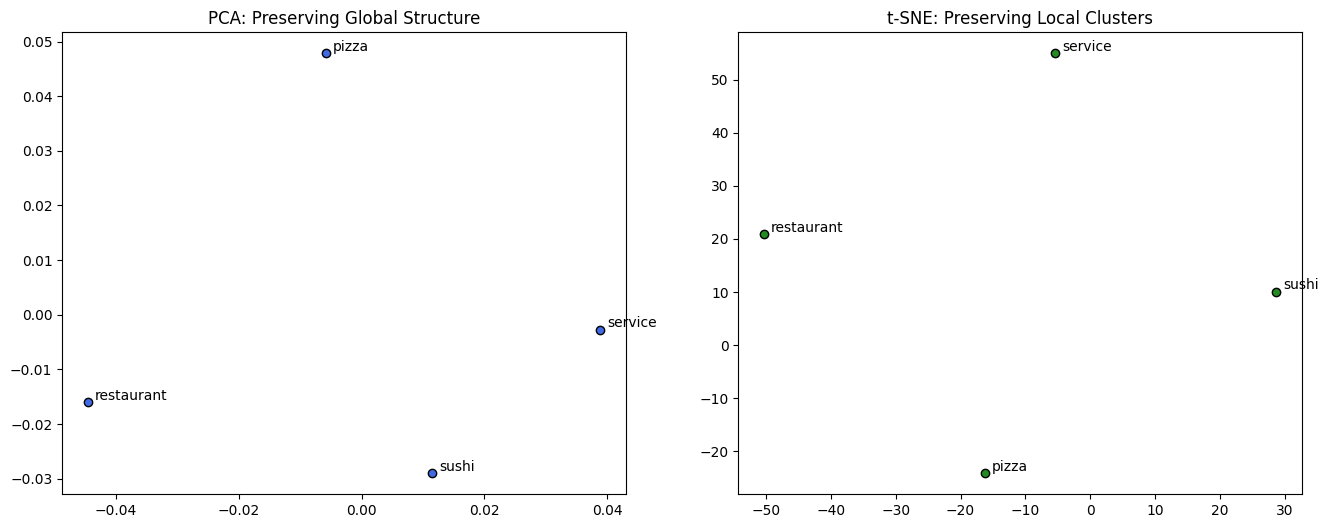

In [29]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_reduction_comparison(model, target_words):
    # 1. Extract vectors
    valid_words = [w for w in target_words if w in model.wv]
    vectors = np.array([model.wv[w] for w in valid_words])
    
    # 2. Compute PCA (Linear)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(vectors)
    
    # 3. Compute t-SNE (Non-linear)
    # Perplexity should be smaller than the number of points
    tsne = TSNE(n_components=2, perplexity=min(5, len(valid_words)-1), random_state=42)
    tsne_result = tsne.fit_transform(vectors)
    
    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # PCA Plot
    ax1.scatter(pca_result[:, 0], pca_result[:, 1], c='royalblue', edgecolors='k')
    for i, word in enumerate(valid_words):
        ax1.annotate(word, (pca_result[i, 0], pca_result[i, 1]), xytext=(5,2), textcoords='offset points')
    ax1.set_title('PCA: Preserving Global Structure')
    
    # t-SNE Plot
    ax2.scatter(tsne_result[:, 0], tsne_result[:, 1], c='forestgreen', edgecolors='k')
    for i, word in enumerate(valid_words):
        ax2.annotate(word, (tsne_result[i, 0], tsne_result[i, 1]), xytext=(5,2), textcoords='offset points')
    ax2.set_title('t-SNE: Preserving Local Clusters')
    
    plt.show()

# Example list of words to compare
words_to_plot = ['salary', 'bonus', 'pay', 'income', 'coding', 'python', 'java', 'software', 'manager', 'director', 'ceo', 'lead']
# Filter words that exist in the model vocabulary
valid_words = [w for w in words_to_plot if w in w2v_model_bigrams.wv]
if valid_words:
    visualize_reduction_comparison(w2v_model_bigrams, valid_words)
else:
    # Fallback to model vocabulary if no target words found
    fallback_words = w2v_model_bigrams.wv.index_to_key[:12]
    visualize_reduction_comparison(w2v_model_bigrams, fallback_words)